## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library liabrary built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

# Loading Data

In [2]:
df = pd.read_csv("/Users/williamdang/Documents/Education/Data/education_clean.csv")

In [3]:
df.head(10)

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804.0,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709.0,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709.0,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958.0,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934.0,Regular School,High,No
5,100019000050,0.080120,0.673492,0.483333,50649.0,17.034188,0.425118,2016-2017,DE,19904.0,Regular School,High,No
6,100020000238,0.075058,0.750751,0.515685,12825.0,18.387057,0.338928,2016-2017,DE,19711.0,Regular School,High,No
7,100020000239,0.075424,0.616605,0.595445,59861.0,15.544567,0.372116,2016-2017,DE,19702.0,Regular School,High,No
8,100020000240,0.114201,0.594220,0.672059,62078.0,14.980464,0.352801,2016-2017,DE,19713.0,Regular School,High,No
9,100023000209,0.039931,0.540456,0.840810,61031.0,15.105006,0.358939,2016-2017,DE,19720.0,Regular School,High,No


## Exploratory data analysis

# Examine distributions and relationships

Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables

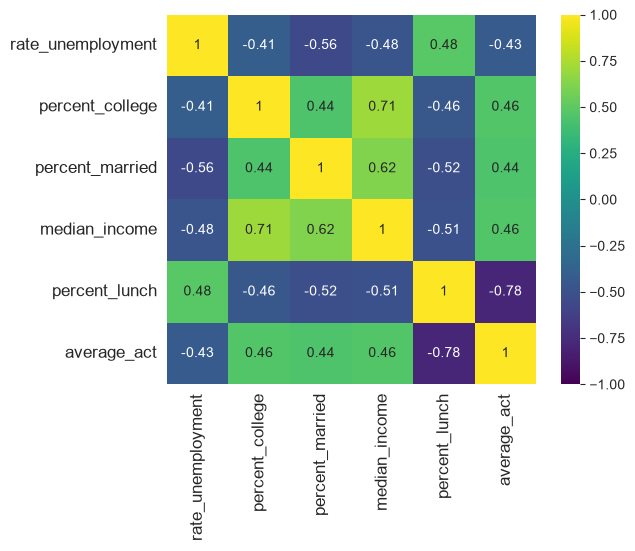

In [4]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors +["average_act"]].corr()

sns.heatmap(
    corr_matrix, vmax= 1, vmin = -1, square = True, annot = True, cmap = "viridis"
)

plt.tick_params(labelsize=12)

plt.show()
    

Make pair plots to explore relationships between the variables

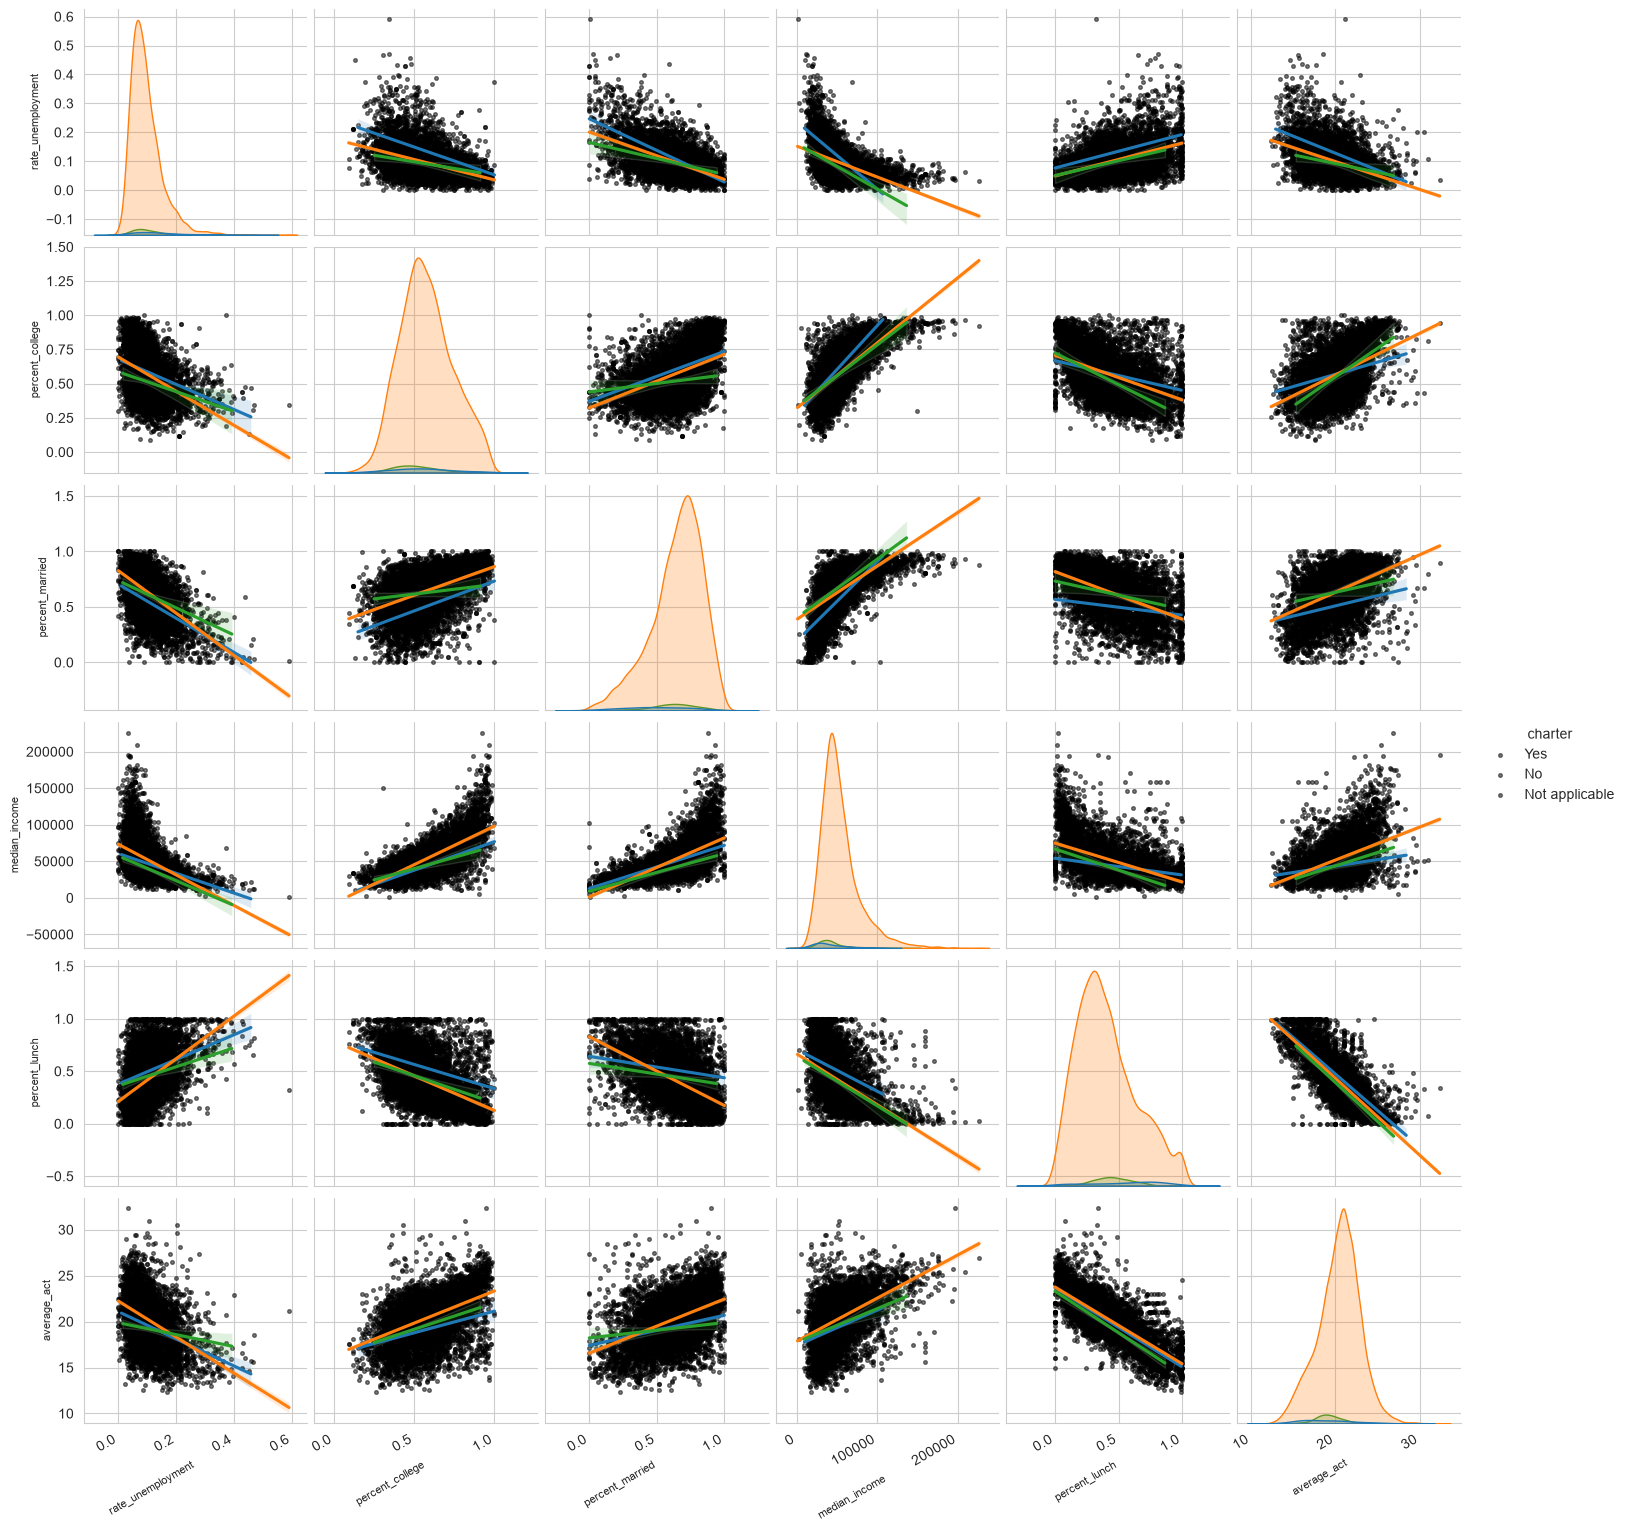

In [5]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors +['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
    }
)

for ax in fig.axes.flat:
    if ax.get_xlabel()== 'CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') #x=axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

   # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

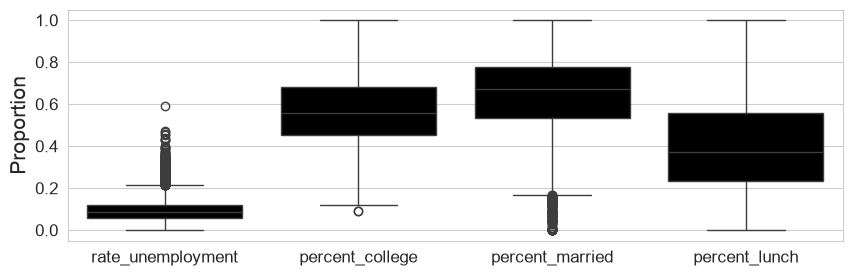

In [6]:
plt.figure(figsize=(10,3))
fractions = list(numerical_predictors)
fractions.remove('median_income')



sns.boxplot(data=df[fractions], color='k')
plt.ylabel('Proportion', fontsize=15)
plt.tick_params(labelsize=12)
plt.show()

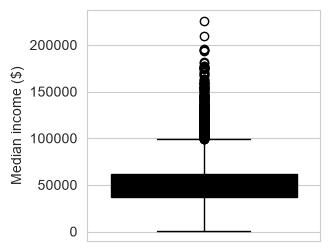

In [7]:
plt.figure(figsize=(3,3))
sns.boxplot(data=df, y='median_income', color='k')
plt.ylabel('Median income ($)')
plt.show()

# ACT Performance: Charter vs. Non-Charter High Schools

##2. Define the two groups
The charter column has three values:

In [10]:
df["charter"].value_counts().groupby('state')

state  charter       
DE     No                 23
       Yes                 1
FL     No                373
       Yes                31
GA     No                361
       Yes                 6
IL     No                554
       Yes                10
IN     No                317
       Yes                 4
KY     Not applicable    198
LA     No                187
       Yes                 6
       Not applicable      1
MA     No                244
       Yes                 9
MI     No                471
       Yes                27
MO     No                332
       Yes                 5
NC     No                407
NJ     No                333
       Yes                 5
NY     No                287
       Yes                 8
OH     No                650
       Yes                 4
PA     No                528
       Yes                15
TN     No                261
       Yes                 4
TX     No                886
       Yes                27
WA     No            

`Not applicable` comes from **Kentucky**, which had no charter school law in 2016–17, so those schools are regular public schools. We group them with `No`:

- **Charter** = `Yes`
- **Non-charter** = `No` + `Not applicable`

In [11]:
df["group"] = np.where(df["charter"] == "Yes", "Charter", "Non-charter")
df["group"].value_counts()

group
Non-charter    7057
Charter         170
Name: count, dtype: int64

In [14]:
## Summary statistics of ACT by group

In [15]:
summary = df.groupby("group")["average_act"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
summary

,count,mean,median,std,min,max
group,,,,,,
Charter,170,19.02,18.89,3.14,12.90,28.40
Non-charter,7057,20.33,20.54,2.48,12.36,32.36


In [13]:
charter = df.loc[df["group"] == "Charter", "average_act"]
non_charter = df.loc[df["group"] == "Non-charter", "average_act"]

print(f"Difference in means (charter − non-charter): {charter.mean() - non_charter.mean():.2f} ACT points")
print(f"Difference in medians:                       {charter.median() - non_charter.median():.2f} ACT points")

Difference in means (charter − non-charter): -1.31 ACT points
Difference in medians:                       -1.65 ACT points


**Interpretation**: 
Charter schools average about 19.0 on the ACT compared with about 20.3 for non-charter schools, a gap of roughly 1.3 points. At the same time, the medians tell a similar story (18.9 vs 20.5). Charter schools also have a larger standard deviation (3.1 vs 2.5), so their scores are more spread out: some charters score very high, others very low.

##Create a plot to visualize

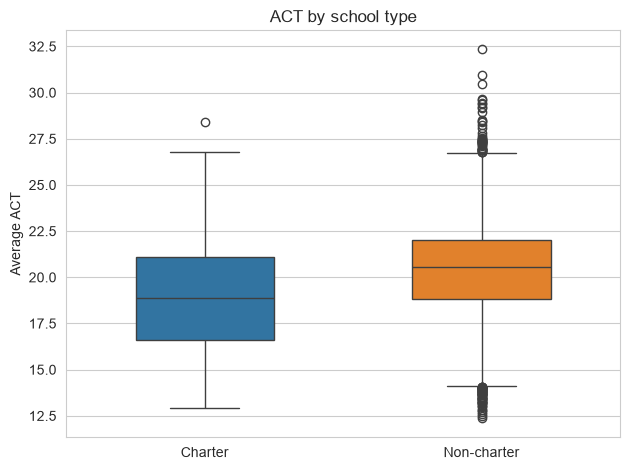

In [19]:
sns.boxplot(data=df, x="group", y="average_act", hue="group",
            legend=False, width=0.5)
plt.xlabel("")
plt.ylabel("Average ACT")
plt.title("ACT by school type")

plt.tight_layout()
plt.show()

## Is the difference statistically significant?

# Import Library

In [20]:
from scipy import stats

We use Welch's two-sample t-test, which compares two group means without assuming equal variances. That fits here because the groups differ in both size and spread.

Null hypothesis (H₀): charter and non-charter schools have the same mean ACT.
Alternative (H₁): the means are different.
Significance level: α = 0.05

In [21]:
t_result = stats.ttest_ind(charter, non_charter, equal_var=False)   # Welch's t-test
ci = t_result.confidence_interval(confidence_level=0.95)

print(f"t-statistic: {t_result.statistic:.2f}")
print(f"p-value:     {t_result.pvalue:.2e}")
print(f"95% CI for the difference in means: [{ci.low:.2f}, {ci.high:.2f}] ACT points")

t-statistic: -5.39
p-value:     2.24e-07
95% CI for the difference in means: [-1.79, -0.83] ACT points


## Interpretation

The p-value is far below 0.05, so we reject the null hypothesis: the difference in average ACT between charter and non-charter schools is statistically significant.
The 95% confidence interval for the gap is roughly −1.8 to −0.8 points. We're fairly confident charter schools average between 0.8 and 1.8 points lower.